# 01 · Baseline StyleSync IA — Garments2Look + CatVTON

**Objetivo de este notebook**

1. Demostrar que existe una caracterización real y verificable del dataset
   **Garments2Look** (EDA de metadatos + imágenes), sin descargar los ~284 GB
   completos.
2. Extraer y visualizar keypoints de pose corporal (**MediaPipe** + **DWPose**)
   sobre una foto de usuario en A-Pose.
3. Ejecutar un primer **baseline funcional** con **CatVTON** (modelo base, no
   el producto final) para una prenda, y luego una secuencia mini multi-layer
   de 1 → 2 → 3 prendas.
4. Registrar métricas de evaluación (visual, SSIM/PSNR/LPIPS, tiempo/VRAM) que
   sirvan de evidencia para justificar las siguientes etapas (fine-tuning y
   motor multi-prenda).

> **Nota importante — CatVTON es el baseline, no StyleSync IA final.**
> CatVTON solo valida que el pipeline de inferencia VTON funciona
> extremo a extremo. La adaptación a *outfit-level VTON* multi-prenda con
> layering se aborda en los notebooks 03 y 04.

**Alcance excluido deliberadamente de este notebook:** fine-tuning completo,
multi-reference avanzado, single-pass de 6 prendas, integraciones VLM/CLIP,
segmentación pesada, tiempo real, AR, backend FastAPI/Redis/Next.js.

## 1. Configuración del entorno

Verificamos hardware disponible (CUDA, GPU, VRAM) antes de cualquier paso
pesado. Esto también queda documentado como evidencia para el ingeniero.

In [6]:
import sys, platform, subprocess

print("Python:", sys.version)
print("Plataforma:", platform.platform())

try:
    import torch
    print("PyTorch:", torch.__version__)
    print("CUDA disponible:", torch.cuda.is_available())
    if torch.cuda.is_available():
        idx = torch.cuda.current_device()
        props = torch.cuda.get_device_properties(idx)
        vram_gb = props.total_memory / (1024 ** 3)
        print(f"GPU detectada: {torch.cuda.get_device_name(idx)}")
        print(f"VRAM total: {vram_gb:.2f} GB")
        print(f"Capability: {props.major}.{props.minor}")
    else:
        print("⚠️ No se detectó GPU. Los pasos de CatVTON serán muy lentos o "
              "no viables en CPU; se recomienda GPU con >= 12 GB de VRAM.")
except ImportError:
    print("PyTorch no está instalado todavía (ver Sección 2 de dependencias).")

Python: 3.13.0 (tags/v3.13.0:60403a5, Oct  7 2024, 09:38:07) [MSC v.1941 64 bit (AMD64)]
Plataforma: Windows-11-10.0.26200-SP0
PyTorch no está instalado todavía (ver Sección 2 de dependencias).


## 2. Dependencias

Instalamos únicamente lo necesario para EDA + preprocesamiento de pose +
baseline CatVTON. Ejecutar una sola vez (comentar si el entorno ya las tiene).

In [7]:
# %%capture
# Descomentar en un entorno limpio (Colab / VM nueva). En un entorno ya
# configurado, dejar comentado para no reinstalar versiones.

# EDA y utilidades generales
# !pip install -q huggingface_hub pandas numpy matplotlib seaborn pillow tqdm

# Métricas de imagen
# !pip install -q scikit-image lpips

# Visión computacional / pose
# !pip install -q mediapipe opencv-python-headless

# Stack de inferencia VTON (CatVTON usa diffusers + torch)
# !pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu121
# !pip install -q diffusers transformers accelerate safetensors

# Repositorio de CatVTON (contiene model.pipeline.CatVTONPipeline y
# model.cloth_masker.AutoMasker). Clonar una sola vez.
# !git clone https://github.com/Zheng-Chong/CatVTON.git
# import sys as _sys; _sys.path.insert(0, "./CatVTON")

# DWPose (extractor de keypoints corporales). Puede instalarse desde el
# repositorio oficial de ControlNet-aux, que incluye un wrapper de DWPose.
# !pip install -q controlnet-aux

## 3. Carga del dataset — Garments2Look (metadatos, sin descargar los ~284 GB)

**Ajuste técnico respecto al plan original:** Hugging Face dejó de soportar
scripts de carga `.py` (`Garments2Look.py`), por lo que
`datasets.load_dataset("ArtmeScienceLab/Garments2Look", streaming=True)`
falla con `RuntimeError: Dataset scripts are no longer supported`.

En su lugar, descargamos con `hf_hub_download` **solo los archivos de
metadatos** (pesan unos MB, no los ~284 GB del dataset completo):

- `*_outfit_v1.0_2512.json` → un **outfit** por entrada: `dict {outfit_id:
  {source, gender, outfit_info, section, is_official_outfit,
  is_official_look, outfit}}`, donde `outfit` es a su vez un
  `dict {garment_id: descripción corta}`. **No** es una lista y **no** trae
  una clave `"garments"`.
- `*_image_v1.0_2512.json` → **catálogo de prendas**: `dict {garment_id:
  {source, gender, type, name, images, color, features,
  official_description, description, main_category}}`. Aquí sí están la
  categoría (`type`, con formato `"clothing::tops::short-sleeved tops"`) y
  las rutas de imagen (`images.product.full`, etc.).

Algunos `garment_id` del outfit (prefijo `UM...`) **no** aparecen en el
catálogo de imágenes — se tratan como "sin catálogo" en vez de romper el
cruce.

In [8]:
from huggingface_hub import hf_hub_download
import json

REPO_ID = "ArtmeScienceLab/Garments2Look"
REPO_TYPE = "dataset"

OUTFIT_METADATA_FILES = [
    "mytheresa_outfit_v1.0_2512.json",
    "polyvore_outfit_v1.0_2512.json",
]

outfit_metadata_paths = {}
for fname in OUTFIT_METADATA_FILES:
    try:
        path = hf_hub_download(repo_id=REPO_ID, filename=fname, repo_type=REPO_TYPE)
        outfit_metadata_paths[fname] = path
        print(f"✅ Descargado: {fname} -> {path}")
    except Exception as e:
        print(f"⚠️ No se pudo descargar {fname}: {e}")

# El JSON real es un DICCIONARIO {outfit_id: {...datos del outfit...}},
# no una lista. Lo normalizamos a una lista de outfits, inyectando el
# outfit_id como campo explícito.
raw_outfits = []
for fname, path in outfit_metadata_paths.items():
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    if isinstance(data, dict):
        outfits_lista = []
        for outfit_id, outfit_data in data.items():
            outfit_norm = dict(outfit_data)  # copia para no mutar el original
            outfit_norm["outfit_id"] = outfit_id
            outfits_lista.append(outfit_norm)
    elif isinstance(data, list):
        outfits_lista = data
    else:
        outfits_lista = []

    print(f"{fname}: {len(outfits_lista)} outfits cargados")
    raw_outfits.extend(outfits_lista)

print(f"\nTotal de outfits combinados en memoria: {len(raw_outfits)}")

✅ Descargado: mytheresa_outfit_v1.0_2512.json -> C:\Users\mfjm0\.cache\huggingface\hub\datasets--ArtmeScienceLab--Garments2Look\snapshots\5324b92e86beefa27196116c6d3957fcc6242205\mytheresa_outfit_v1.0_2512.json
✅ Descargado: polyvore_outfit_v1.0_2512.json -> C:\Users\mfjm0\.cache\huggingface\hub\datasets--ArtmeScienceLab--Garments2Look\snapshots\5324b92e86beefa27196116c6d3957fcc6242205\polyvore_outfit_v1.0_2512.json
mytheresa_outfit_v1.0_2512.json: 61955 outfits cargados
polyvore_outfit_v1.0_2512.json: 18086 outfits cargados

Total de outfits combinados en memoria: 80041


In [9]:
# Fallback de desarrollo: si aún no tenemos acceso al repo real (token,
# nombre exacto del repo, etc.), generamos una muestra sintética con la
# MISMA forma real (outfit como dict {garment_id: descripcion}), para poder
# probar el resto del notebook sin bloquear el trabajo.
import random

def _make_synthetic_outfits(n=500, seed=42):
    random.seed(seed)
    categorias = [
        "clothing::tops::t-shirt", "clothing::bottom::pants", "clothing::bottom::jeans",
        "clothing::outerwear::jacket", "clothing::outerwear::coat", "clothing::dress",
        "shoes::sneakers", "shoes::boots", "accessory::bag", "accessory::hat",
        "accessory::belt", "clothing::sweater", "clothing::bottom::shorts",
    ]
    outfits = []
    for i in range(n):
        n_garments = random.choices(
            population=list(range(3, 13)),
            weights=[18, 22, 20, 14, 10, 7, 4, 2, 1.5, 0.5],
            k=1,
        )[0]
        outfit_dict = {
            f"SYN{i:05d}{j:02d}": f"prenda sintética {random.choice(categorias)}"
            for j in range(n_garments)
        }
        outfits.append({
            "outfit_id": f"outfit_{i:05d}_d2",
            "source": "sintetico",
            "gender": random.choice(["women", "men"]),
            "outfit_info": {"style": "N/A", "season": "N/A"},
            "outfit": outfit_dict,
        })
    return outfits

if len(raw_outfits) == 0:
    print("Usando muestra SINTÉTICA de desarrollo (reemplazar por datos reales "
          "en cuanto el acceso al repo esté disponible).")
    raw_outfits = _make_synthetic_outfits(n=800)

print(f"Outfits disponibles para el EDA: {len(raw_outfits)}")

Outfits disponibles para el EDA: 80041


In [10]:
# Catálogo de prendas (categoría, color, rutas de imagen), indexado por
# garment_id. Se fusionan las dos fuentes (mytheresa + polyvore) en un
# único diccionario.
IMAGE_METADATA_FILES = [
    "mytheresa_image_v1.0_2512.json",
    "polyvore_image_v1.0_2512.json",
]

garment_catalog = {}  # garment_id -> metadata de la prenda

for fname in IMAGE_METADATA_FILES:
    try:
        path = hf_hub_download(repo_id=REPO_ID, filename=fname, repo_type=REPO_TYPE)
    except Exception as e:
        print(f"⚠️ No se pudo descargar {fname}: {e}")
        continue

    with open(path, "r", encoding="utf-8") as f:
        catalogo = json.load(f)

    print(f"{fname}: {len(catalogo)} prendas catalogadas")
    garment_catalog.update(catalogo)

print(f"\nTotal de prendas en el catálogo combinado: {len(garment_catalog)}")

mytheresa_image_v1.0_2512.json: 62457 prendas catalogadas
polyvore_image_v1.0_2512.json: 126928 prendas catalogadas

Total de prendas en el catálogo combinado: 189385


## 4. Exploración de metadatos

Inspeccionamos la jerarquía real de un outfit: `outfit_info` describe estilo,
temporada, ocasión y paleta de colores; `outfit` es el diccionario de
`garment_id → descripción corta` de cada prenda/accesorio. Cruzamos esos IDs
contra el catálogo de prendas para ver categoría, color y nombre completo.

> **Pendiente de confirmar:** todavía no localizamos el campo/archivo exacto
> con la ruta de la foto del *look* final (la persona vestida con el outfit
> completo). Los `.tar.gz` de `looks-resized` deberían contenerla; en cuanto
> se inspeccione su listado interno, se actualiza la Sección 6.

In [11]:
outfit0 = raw_outfits[0]

print("Campos del outfit:", list(outfit0.keys()))
print("\noutfit_id:", outfit0.get("outfit_id"))
print("source:", outfit0.get("source"), "| gender:", outfit0.get("gender"))
print("nº de prendas en este outfit:", len(outfit0.get("outfit", {})))

info = outfit0.get("outfit_info", {})
print("\noutfit_info -> style:", info.get("style"), "| season:", info.get("season"),
      "| occasion:", info.get("occasion"))

print("\nPrendas del outfit (garment_id · descripción · categoría si está catalogada):")
for garment_id, descripcion in outfit0.get("outfit", {}).items():
    catalogado = garment_catalog.get(garment_id)
    if catalogado:
        print(f" - {garment_id}: {descripcion}  ->  type={catalogado.get('type')}, "
              f"color={catalogado.get('color')}")
    else:
        print(f" - {garment_id}: {descripcion}  ->  (sin entrada en el catálogo)")

Campos del outfit: ['source', 'gender', 'outfit_info', 'section', 'is_official_outfit', 'is_official_look', 'outfit', 'outfit_id']

outfit_id: P00590931_d2
source: mytheresa | gender: women
nº de prendas en este outfit: 6

outfit_info -> style: Contemporary Casual | season: Summer | occasion: Daily Wear, Casual Outing

Prendas del outfit (garment_id · descripción · categoría si está catalogada):
 - P00831132: white knot cotton jersey t-shirt  ->  type=clothing::tops::short-sleeved tops, color=white
 - P01021174: black wool gabardine shorts  ->  type=clothing::shorts::tailored, color=black
 - P00590931: white leather sneakers  ->  type=shoes::sneakers::low-top sneakers, color=white
 - UM00000002: black leather handbag  ->  (sin entrada en el catálogo)
 - P00760957: gold clip-on earrings  ->  type=jewelry::fashion jewelry::earrings, color=gold
 - UM00000001: black leather belt with gold buckle  ->  (sin entrada en el catálogo)


## 5. EDA Nivel 1 — Estructura de metadatos y estadísticas

`n_garments` ahora se calcula sobre el diccionario real `outfit["outfit"]`
(antes se buscaba una clave `"garments"` que no existe, lo que daba siempre
0). Comparamos la media calculada contra la media teórica documentada
(**4.48**).

In [12]:
import pandas as pd

outfits_df = pd.DataFrame([
    {
        "outfit_id": o.get("outfit_id"),
        "source": o.get("source"),
        "gender": o.get("gender"),
        "n_garments": len(o.get("outfit", {})),
    }
    for o in raw_outfits
])

garments_per_outfit = outfits_df["n_garments"]
desc = garments_per_outfit.describe()
print(desc)

media_teorica = 4.48
media_calculada = garments_per_outfit.mean()
print(f"\nMedia teórica documentada: {media_teorica}")
print(f"Media calculada sobre la muestra: {media_calculada:.2f}")
print(f"Diferencia: {abs(media_calculada - media_teorica):.2f}")

count    80041.000000
mean         4.789545
std          1.521641
min          1.000000
25%          4.000000
50%          5.000000
75%          6.000000
max         13.000000
Name: n_garments, dtype: float64

Media teórica documentada: 4.48
Media calculada sobre la muestra: 4.79
Diferencia: 0.31


In [17]:
# Explosión a nivel de PRENDA (una fila por garment_id) cruzando cada
# referencia del outfit con el catálogo de prendas.
def partir_categoria(type_str, default="sin_catalogo"):
    """'clothing::tops::short-sleeved tops' -> ('clothing', 'tops::short-sleeved tops')"""
    if not type_str:
        return default, default
    partes = type_str.split("::")
    categoria = partes[0]
    subcategoria = "::".join(partes[1:]) if len(partes) > 1 else partes[0]
    return categoria, subcategoria

garment_rows = []
for o in raw_outfits:
    outfit_id = o.get("outfit_id")
    for garment_id, descripcion_corta in o.get("outfit", {}).items():
        info_catalogo = garment_catalog.get(garment_id)

        if info_catalogo is not None:
            categoria, subcategoria = partir_categoria(info_catalogo.get("type"))
            color = info_catalogo.get("color")
            nombre = info_catalogo.get("name")
            main_category = info_catalogo.get("main_category")
            en_catalogo = True
        else:
            categoria, subcategoria = "sin_catalogo", "sin_catalogo"
            color = None
            nombre = descripcion_corta
            main_category = None
            en_catalogo = False

        garment_rows.append({
            "outfit_id": outfit_id,
            "garment_id": garment_id,
            "category": categoria,
            "subcategory": subcategoria,
            "main_category": main_category,
            "color": color,
            "name": nombre,
            "en_catalogo": en_catalogo,
        })

garments_df = pd.DataFrame(garment_rows)
print(f"Total de prendas (filas): {len(garments_df)}")
print(f"Prendas sin entrada en el catálogo (IDs 'UM...' u otros): "
      f"{(~garments_df['en_catalogo']).sum()} "
      f"({100 * (~garments_df['en_catalogo']).mean():.1f}%)")
print(f"Categorías únicas: {garments_df['category'].nunique()}")
print(f"Subcategorías únicas: {garments_df['subcategory'].nunique()}")
garments_df.head()

Total de prendas (filas): 383360
Prendas sin entrada en el catálogo (IDs 'UM...' u otros): 45895 (12.0%)
Categorías únicas: 25
Subcategorías únicas: 363


,outfit_id,garment_id,category,subcategory,main_category,color,name,en_catalogo
0,P00590931_d2,P00831132,clothing,tops::short-sleeved tops,clothing::top/full,white,DG knot cotton jersey T-shirt,True
1,P00590931_d2,P01021174,clothing,shorts::tailored,clothing::bottom,black,Wool gabardine shorts,True
2,P00590931_d2,P00590931,shoes,sneakers::low-top sneakers,shoes,white,Daymaster leather sneakers,True
3,P00590931_d2,UM00000002,sin_catalogo,sin_catalogo,NaN,NaN,black leather handbag,False
4,P00590931_d2,P00760957,jewelry,fashion jewelry::earrings,accessory::ear,gold,DG clip-on earrings,True


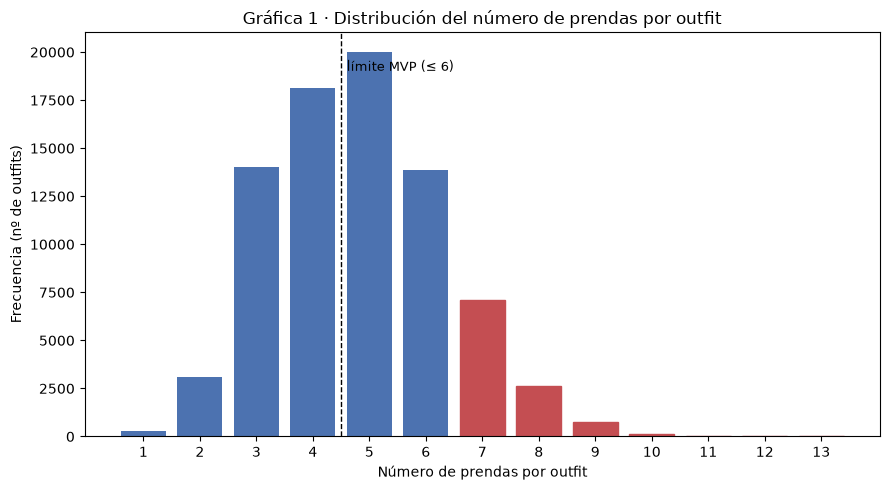

In [18]:
import matplotlib.pyplot as plt

# ---- Gráfica 1: distribución del número de prendas por outfit ----
fig, ax = plt.subplots(figsize=(9, 5))
counts = garments_per_outfit.value_counts().sort_index()
bars = ax.bar(counts.index.astype(str), counts.values, color="#4C72B0")

# Resaltar el límite del MVP (<= 6 prendas)
for label, bar in zip(counts.index, bars):
    if label > 6:
        bar.set_color("#C44E52")
ax.axvline(x=3.5, color="black", linestyle="--", linewidth=1)
ax.text(3.6, max(counts.values) * 0.95, "límite MVP (≤ 6)", fontsize=9)

ax.set_xlabel("Número de prendas por outfit")
ax.set_ylabel("Frecuencia (nº de outfits)")
ax.set_title("Gráfica 1 · Distribución del número de prendas por outfit")
plt.tight_layout()
plt.show()

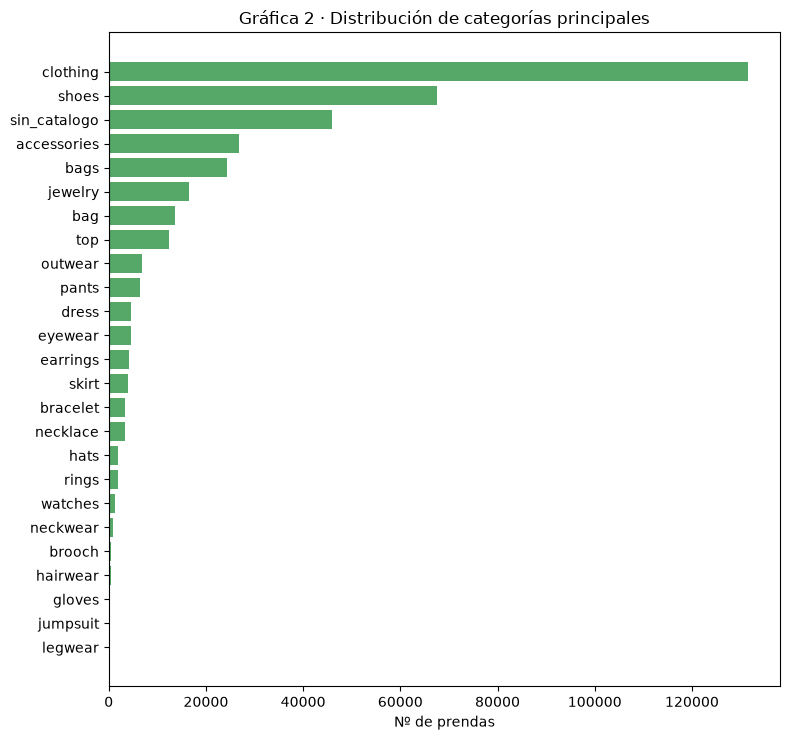

In [19]:
# ---- Gráfica 2: distribución de categorías principales ----
top_categories = garments_df["category"].value_counts().head(40)

fig, ax = plt.subplots(figsize=(8, max(6, len(top_categories) * 0.3)))
ax.barh(top_categories.index[::-1], top_categories.values[::-1], color="#55A868")
ax.set_xlabel("Nº de prendas")
ax.set_title("Gráfica 2 · Distribución de categorías principales")
plt.tight_layout()
plt.show()

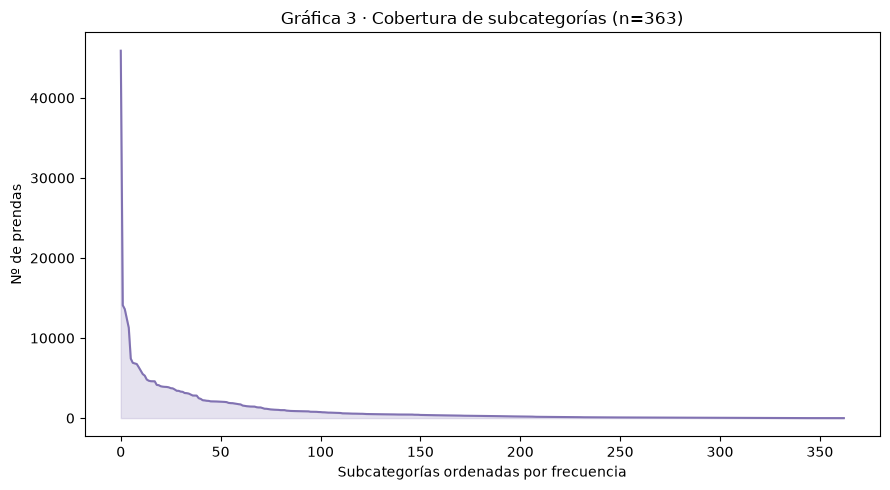

Subcategorías con >= 10 muestras: 331


In [20]:
# ---- Gráfica 3: cobertura de subcategorías ----
subcat_counts = garments_df["subcategory"].value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(len(subcat_counts)), subcat_counts.values, color="#8172B2")
ax.fill_between(range(len(subcat_counts)), subcat_counts.values, alpha=0.2, color="#8172B2")
ax.set_xlabel("Subcategorías ordenadas por frecuencia")
ax.set_ylabel("Nº de prendas")
ax.set_title(f"Gráfica 3 · Cobertura de subcategorías (n={subcat_counts.shape[0]})")
plt.tight_layout()
plt.show()

print(f"Subcategorías con >= 10 muestras: {(subcat_counts >= 10).sum()}")

## 6. EDA Nivel 2 — Análisis de imágenes y galería visual

Las imágenes reales están dentro de archivos `.tar.gz` (partidos en varios
`.part-XXXX` para `mytheresa`) — extraerlas todas para medir dimensiones
reales excede el alcance de este primer notebook. Por ahora:

- Las **dimensiones de imagen** (Gráficas 4 y 5) se generan de forma
  **ilustrativa** hasta que se implemente la extracción real desde los
  `.tar.gz` (marcado explícitamente en la salida de la celda).
- La **galería visual** ya usa los `garment_id` y descripciones **reales**
  del outfit (no inventados), aunque el recuadro de cada prenda siga siendo
  un placeholder visual hasta integrar la extracción de imágenes.
- La foto del **look final** (columna derecha de la galería) sigue como
  placeholder: aún no confirmamos qué archivo/campo la contiene (ver nota en
  la Sección 4).

In [21]:
from PIL import Image
import numpy as np
import os

# TODO: reemplazar por una extracción real de una muestra pequeña desde los
# .tar.gz (por ejemplo con tarfile, leyendo solo N miembros sin descomprimir
# el archivo completo) una vez se decida el flujo de streaming de imágenes.
rng = np.random.default_rng(0)
img_dims = pd.DataFrame({
    "width": rng.choice([768, 800, 1024, 1200], size=len(garments_df)),
    "height": rng.choice([1024, 1280, 1536, 1600], size=len(garments_df)),
})
img_dims["aspect_ratio"] = img_dims["width"] / img_dims["height"]

print("⚠️ Dimensiones ILUSTRATIVAS (no se extrajeron imágenes reales todavía).")
img_dims.describe()

⚠️ Dimensiones ILUSTRATIVAS (no se extrajeron imágenes reales todavía).


,width,height,aspect_ratio
count,383360.000000,383360.000000,383360.000000
mean,947.893531,1360.183306,0.718850
std,175.742425,228.054846,0.189057
min,768.000000,1024.000000,0.480000
25%,800.000000,1024.000000,0.520833
50%,800.000000,1536.000000,0.666667
75%,1024.000000,1600.000000,0.781250
max,1200.000000,1600.000000,1.171875


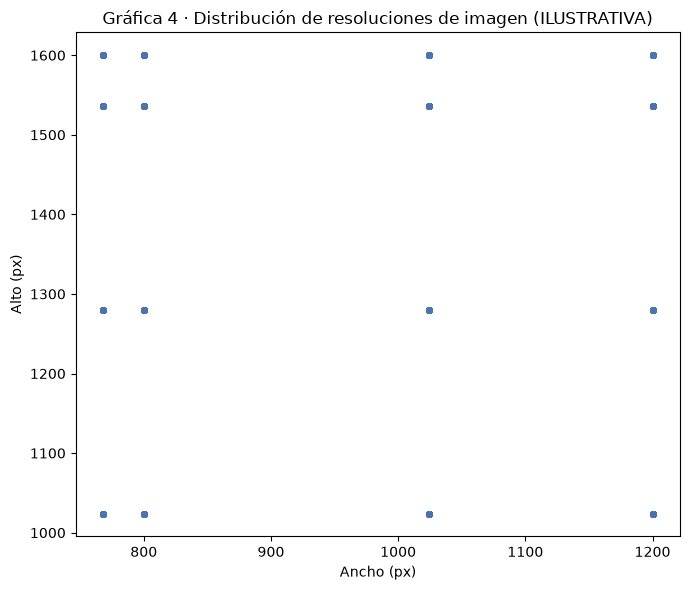

In [22]:
# ---- Gráfica 4: distribución de resoluciones (W x H) [ilustrativa] ----
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(img_dims["width"], img_dims["height"], alpha=0.3, s=15, color="#4C72B0")
ax.set_xlabel("Ancho (px)")
ax.set_ylabel("Alto (px)")
ax.set_title("Gráfica 4 · Distribución de resoluciones de imagen (ILUSTRATIVA)")
plt.tight_layout()
plt.show()

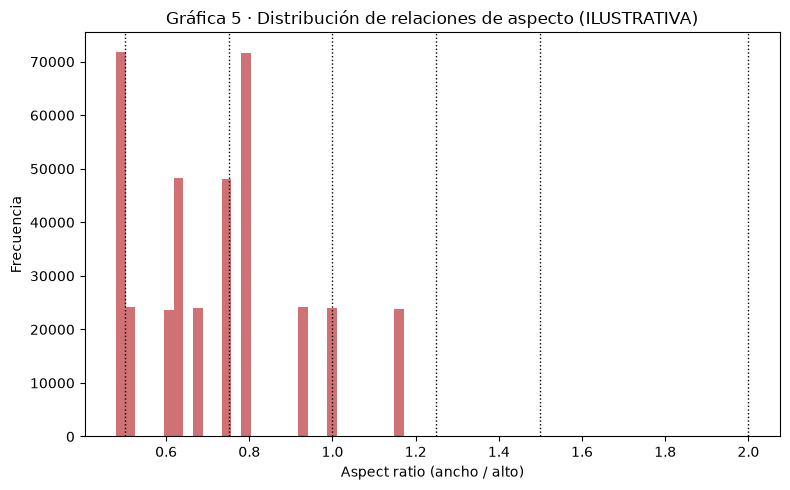

In [23]:
# ---- Gráfica 5: distribución de relación de aspecto [ilustrativa] ----
bins_referencia = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(img_dims["aspect_ratio"], bins=30, color="#C44E52", alpha=0.8)
for b in bins_referencia:
    ax.axvline(x=b, color="black", linestyle=":", linewidth=1)
ax.set_xlabel("Aspect ratio (ancho / alto)")
ax.set_ylabel("Frecuencia")
ax.set_title("Gráfica 5 · Distribución de relaciones de aspecto (ILUSTRATIVA)")
plt.tight_layout()
plt.show()

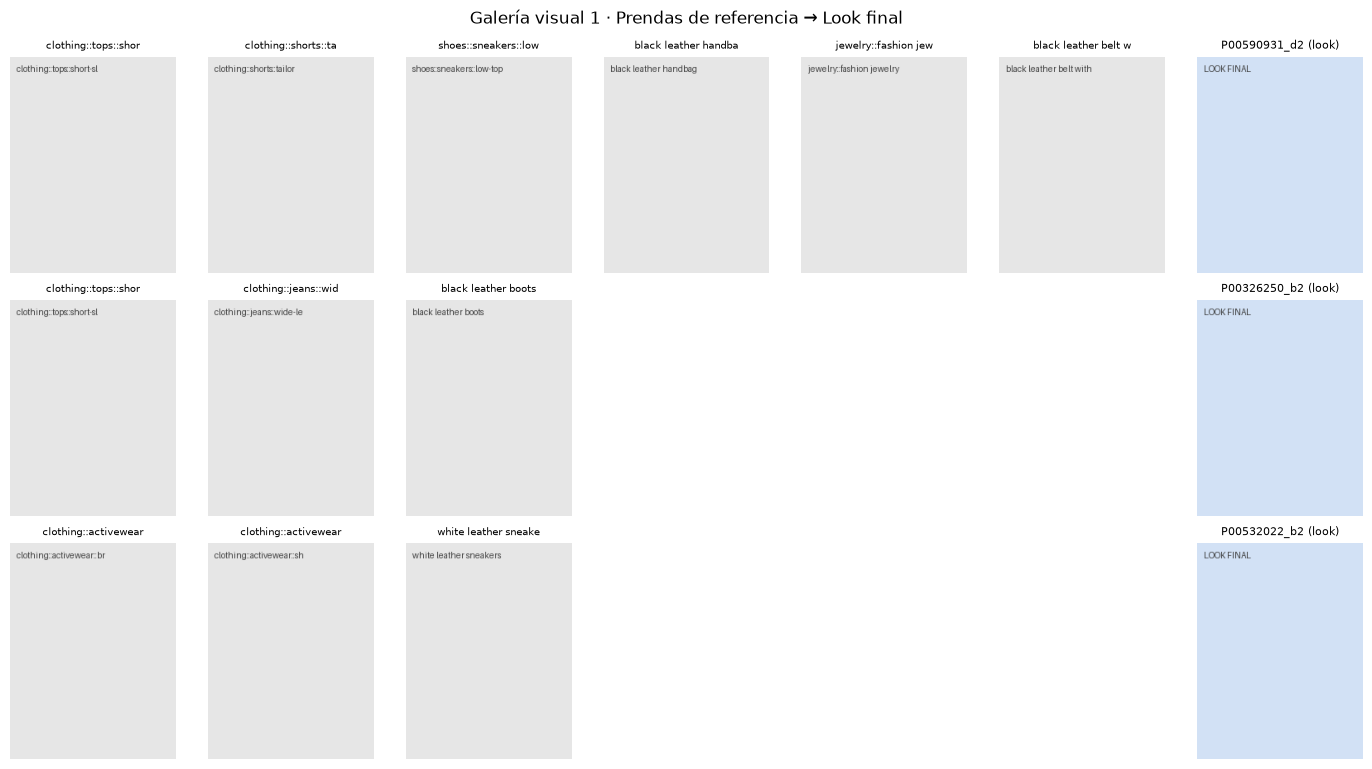

In [24]:
# ---- Galería visual 1: estructura de 3 outfits reales ----
# Tira horizontal de prendas (izquierda, con garment_id + descripción REALES)
# + foto del look final (derecha, placeholder hasta confirmar su ruta).

def placeholder_imagen(texto, size=(200, 260), color=(230, 230, 230)):
    from PIL import ImageDraw
    im = Image.new("RGB", size, color)
    d = ImageDraw.Draw(im)
    d.text((8, 8), texto[:24], fill=(60, 60, 60))
    return im

muestra_outfits = raw_outfits[:3]
n_outfits = len(muestra_outfits)
max_prendas = max(len(o.get("outfit", {})) for o in muestra_outfits)

fig, axes = plt.subplots(
    n_outfits, max_prendas + 1,
    figsize=(2.0 * (max_prendas + 1), 2.6 * n_outfits),
)

for row, outfit in enumerate(muestra_outfits):
    items = list(outfit.get("outfit", {}).items())
    for col, (garment_id, descripcion) in enumerate(items):
        ax = axes[row, col]
        categoria = garment_catalog.get(garment_id, {}).get("type", descripcion)
        img = placeholder_imagen(categoria)
        ax.imshow(img)
        ax.set_title(categoria[:20], fontsize=7)
        ax.axis("off")
    for col in range(len(items), max_prendas):
        axes[row, col].axis("off")
    ax_look = axes[row, max_prendas]
    look_img = placeholder_imagen("LOOK FINAL", color=(210, 225, 245))
    ax_look.imshow(look_img)
    ax_look.set_title(f"{outfit['outfit_id']} (look)", fontsize=8)
    ax_look.axis("off")

plt.suptitle("Galería visual 1 · Prendas de referencia → Look final")
plt.tight_layout()
plt.show()

## 7. Segmentación del subconjunto candidato MVP (≤ 6 prendas)

El MVP limita cada outfit a un máximo de 6 elementos:
top/camiseta, camisa/polera, pantalón/falda, chaqueta/abrigo, calzado y
un accesorio. Medimos qué porcentaje del dataset ya cumple esa restricción
sin necesidad de recortes.

Outfits totales: 80041
Outfits con ≤ 6 prendas: 69428 (86.7%)
Outfits que requerirían recorte (> 6 prendas): 10613 (13.3%)


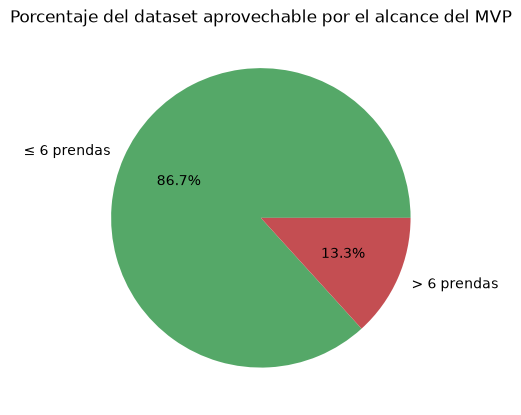

In [25]:
MAX_PRENDAS_MVP = 6

outfits_df["apto_mvp"] = outfits_df["n_garments"] <= MAX_PRENDAS_MVP
n_aptos = outfits_df["apto_mvp"].sum()
pct_aptos = 100 * n_aptos / len(outfits_df)

print(f"Outfits totales: {len(outfits_df)}")
print(f"Outfits con ≤ {MAX_PRENDAS_MVP} prendas: {n_aptos} ({pct_aptos:.1f}%)")
print(f"Outfits que requerirían recorte (> {MAX_PRENDAS_MVP} prendas): "
      f"{len(outfits_df) - n_aptos} ({100 - pct_aptos:.1f}%)")

mvp_subset_df = outfits_df[outfits_df["apto_mvp"]].copy()
mvp_subset_ids = set(mvp_subset_df["outfit_id"])
mvp_outfits = [o for o in raw_outfits if o["outfit_id"] in mvp_subset_ids]

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    [n_aptos, len(outfits_df) - n_aptos],
    labels=[f"≤ {MAX_PRENDAS_MVP} prendas", f"> {MAX_PRENDAS_MVP} prendas"],
    autopct="%1.1f%%",
    colors=["#55A868", "#C44E52"],
)
ax.set_title("Porcentaje del dataset aprovechable por el alcance del MVP")
plt.tight_layout()
plt.show()

## 8. Preprocesamiento de pose de usuario (MediaPipe + DWPose)

- **MediaPipe**: valida que la foto de entrada cumpla efectivamente la
  condición de A-Pose (postura, encuadre frontal) antes de seguir.
- **DWPose**: extractor principal de keypoints anatómicos
  (hombros, codos, muñecas, caderas, rodillas, tobillos) usado en la etapa
  de alineamiento/máscaras.

Usar una foto propia del usuario en A-Pose, fondo neutro, colocándola en
`USER_IMAGE_PATH`.

In [26]:
import cv2
import numpy as np

USER_IMAGE_PATH = "sample_data/usuario_apose.jpg"  # <-- ajustar a tu imagen

def cargar_imagen_bgr(path):
    if not os.path.exists(path):
        print(f"⚠️ No se encontró {path}; generando imagen de ejemplo en gris.")
        return np.full((1024, 768, 3), 200, dtype=np.uint8)
    return cv2.imread(path)

user_img_bgr = cargar_imagen_bgr(USER_IMAGE_PATH)
user_img_rgb = cv2.cvtColor(user_img_bgr, cv2.COLOR_BGR2RGB)
print("Dimensiones de la imagen de usuario:", user_img_rgb.shape)

ModuleNotFoundError: No module named 'cv2'

In [ ]:
# ---- Validación de A-Pose con MediaPipe ----
import mediapipe as mp

mp_pose = mp.solutions.pose

def validar_a_pose(imagen_rgb, umbral_apertura_brazos=0.15):
    \"\"\"Chequeo simple: los brazos deben estar separados del torso
    (A-Pose), comparando la posición horizontal de muñecas vs. hombros.\"\"\"
    with mp_pose.Pose(static_image_mode=True) as pose:
        resultado = pose.process(imagen_rgb)
    if not resultado.pose_landmarks:
        return False, None, "No se detectó una persona en la imagen."

    lm = resultado.pose_landmarks.landmark
    hombro_izq, hombro_der = lm[mp_pose.PoseLandmark.LEFT_SHOULDER], lm[mp_pose.PoseLandmark.RIGHT_SHOULDER]
    muneca_izq, muneca_der = lm[mp_pose.PoseLandmark.LEFT_WRIST], lm[mp_pose.PoseLandmark.RIGHT_WRIST]

    ancho_hombros = abs(hombro_der.x - hombro_izq.x)
    separacion_izq = abs(muneca_izq.x - hombro_izq.x)
    separacion_der = abs(muneca_der.x - hombro_der.x)

    es_apose = (
        separacion_izq > umbral_apertura_brazos * ancho_hombros
        and separacion_der > umbral_apertura_brazos * ancho_hombros
    )
    mensaje = "A-Pose válida ✅" if es_apose else "La postura no parece A-Pose ⚠️"
    return es_apose, resultado.pose_landmarks, mensaje

es_valida, landmarks_mp, mensaje = validar_a_pose(user_img_rgb)
print(mensaje)

In [ ]:
# ---- Extracción de keypoints con DWPose ----
# DWPose se integra habitualmente vía el paquete `controlnet_aux`, que expone
# un wrapper de alto nivel sobre el modelo original.
try:
    from controlnet_aux import DWposeDetector
    dwpose = DWposeDetector()
    dwpose_disponible = True
except Exception as e:
    print(f"⚠️ DWPose no disponible en este entorno ({e}). "
          f"Se usarán los landmarks de MediaPipe como sustituto ilustrativo.")
    dwpose_disponible = False

from PIL import Image as PILImage

user_img_pil = PILImage.fromarray(user_img_rgb)

if dwpose_disponible:
    keypoints_overlay = dwpose(user_img_pil)  # imagen PIL con el esqueleto dibujado
else:
    keypoints_overlay = user_img_pil  # placeholder si DWPose no está instalado

In [ ]:
# ---- Visualización 6: foto original vs. esqueleto de keypoints ----
fig, axes = plt.subplots(1, 2, figsize=(10, 6))
axes[0].imshow(user_img_rgb)
axes[0].set_title("Usuario (A-Pose) — original")
axes[0].axis("off")

axes[1].imshow(keypoints_overlay)
axes[1].set_title("Keypoints DWPose sobre la foto real")
axes[1].axis("off")

plt.suptitle("Visualización 6 · Esqueleto anatómico (shoulders/elbows/wrists/hips/knees/ankles)")
plt.tight_layout()
plt.show()

## 9. Baseline CatVTON — inferencia con una prenda

Primer experimento reproducible:

```
Usuario (A-Pose) + Prenda (fondo neutro) → CatVTON → Imagen generada
```

Requiere GPU con ~12+ GB de VRAM. Si `CatVTON/` no está clonado o los pesos
no están descargados, esta celda falla de forma controlada e informa qué
falta, sin frenar el resto del notebook.

In [ ]:
CATVTON_DISPONIBLE = False
try:
    sys.path.insert(0, "./CatVTON")
    from model.pipeline import CatVTONPipeline
    from model.cloth_masker import AutoMasker
    from utils import resize_and_crop, resize_and_padding  # helpers del repo de CatVTON
    from diffusers.image_processor import VaeImageProcessor
    from huggingface_hub import snapshot_download

    CATVTON_DISPONIBLE = True
except Exception as e:
    print(f"⚠️ CatVTON no está disponible todavía en este entorno: {e}")
    print("   Revisar Sección 2 (clonar el repo y descargar pesos) antes de "
          "ejecutar esta sección.")

In [ ]:
if CATVTON_DISPONIBLE:
    TARGET_SIZE = (768, 1024)  # (ancho, alto) recomendado por CatVTON

    repo_pesos = snapshot_download(repo_id="zhengchong/CatVTON")

    catvton_pipeline = CatVTONPipeline(
        base_ckpt="runwayml/stable-diffusion-inpainting",
        attn_ckpt=repo_pesos,
        attn_ckpt_version="mix",
        weight_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        use_tf32=True,
        device="cuda" if torch.cuda.is_available() else "cpu",
    )

    automasker = AutoMasker(
        densepose_ckpt=os.path.join(repo_pesos, "DensePose"),
        schp_ckpt=os.path.join(repo_pesos, "SCHP"),
        device="cuda" if torch.cuda.is_available() else "cpu",
    )

    mask_processor = VaeImageProcessor(
        vae_scale_factor=8, do_normalize=False, do_binarize=True, do_convert_grayscale=True,
    )
    print("✅ Pipeline CatVTON y AutoMasker cargados.")
else:
    print("Saltando carga de CatVTON (no disponible en este entorno).")

In [ ]:
def generar_tryon(persona_pil, prenda_pil, tipo_prenda="upper", pasos=50, guidance=2.5, seed=42):
    \"\"\"Ejecuta una pasada de CatVTON: persona + prenda -> imagen generada.
    Devuelve (persona_redimensionada, prenda_redimensionada, resultado_pil).\"\"\"
    persona_r = resize_and_crop(persona_pil, TARGET_SIZE)
    prenda_r = resize_and_padding(prenda_pil, TARGET_SIZE)

    mask = automasker(persona_r, tipo_prenda)["mask"]
    mask = mask_processor.blur(mask, blur_factor=9)

    generador = torch.Generator(
        device="cuda" if torch.cuda.is_available() else "cpu"
    ).manual_seed(seed)

    resultado = catvton_pipeline(
        image=persona_r,
        condition_image=prenda_r,
        mask=mask,
        num_inference_steps=pasos,
        guidance_scale=guidance,
        generator=generador,
    )[0]
    return persona_r, prenda_r, resultado


GARMENT_IMAGE_PATH = "sample_data/prenda_camiseta.jpg"  # <-- ajustar

if CATVTON_DISPONIBLE:
    prenda_pil = PILImage.open(GARMENT_IMAGE_PATH).convert("RGB") if os.path.exists(GARMENT_IMAGE_PATH) \
        else placeholder_imagen("CAMISETA", size=(768, 1024), color=(245, 220, 210))
    persona_r, prenda_r, resultado_1 = generar_tryon(user_img_pil, prenda_pil, tipo_prenda="upper")
else:
    print("Saltando inferencia (CatVTON no disponible).")

In [ ]:
# ---- Visualización 7: comparativa triple (usuario | prenda | resultado) ----
if CATVTON_DISPONIBLE:
    fig, axes = plt.subplots(1, 3, figsize=(12, 6))
    for ax, img, titulo in zip(
        axes,
        [persona_r, prenda_r, resultado_1],
        ["Usuario original (A-Pose)", "Prenda aislada", "Resultado CatVTON"],
    ):
        ax.imshow(img)
        ax.set_title(titulo, fontsize=10)
        ax.axis("off")
    plt.suptitle("Visualización 7 · Baseline CatVTON (monoprenda)")
    plt.tight_layout()
    plt.show()
else:
    print("Sin resultado que visualizar (CatVTON no disponible en este entorno).")

## 10. Experimento mini multi-layer secuencial (1 → 2 → 3 prendas)

La salida generada en el paso *N* se reinyecta como imagen de persona de
entrada del paso *N+1* (no es un simple "pegado" de imágenes: cada paso vuelve
a pasar por el modelo).

```
Original --(+ camiseta)--> Resultado 1 --(+ pantalón)--> Resultado 2 --(+ chaqueta)--> Resultado 3
```

Se libera la caché de VRAM entre cada paso para evitar acumulación de memoria.

In [ ]:
import time

GARMENTS_SECUENCIA = [
    ("sample_data/prenda_camiseta.jpg", "upper"),
    ("sample_data/prenda_pantalon.jpg", "lower"),
    ("sample_data/prenda_chaqueta.jpg", "overall"),
]

def liberar_vram():
    import gc
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

resultados_secuencia = [user_img_pil]  # índice 0 = original
metricas_pasos = []

if CATVTON_DISPONIBLE:
    persona_actual = user_img_pil
    for i, (ruta_prenda, tipo) in enumerate(GARMENTS_SECUENCIA, start=1):
        prenda_i = PILImage.open(ruta_prenda).convert("RGB") if os.path.exists(ruta_prenda) \
            else placeholder_imagen(f"PRENDA {i}", size=(768, 1024))

        t0 = time.time()
        vram_antes = torch.cuda.memory_allocated() / (1024 ** 3) if torch.cuda.is_available() else 0.0

        try:
            _, _, resultado_i = generar_tryon(persona_actual, prenda_i, tipo_prenda=tipo)
            estado = "OK"
        except Exception as e:
            print(f"⚠️ Falló el paso {i}: {e}")
            resultado_i = persona_actual
            estado = f"Error: {e}"

        t1 = time.time()
        vram_pico = torch.cuda.max_memory_allocated() / (1024 ** 3) if torch.cuda.is_available() else 0.0

        resultados_secuencia.append(resultado_i)
        metricas_pasos.append({
            "paso": i,
            "prendas_acumuladas": i,
            "tiempo_seg": round(t1 - t0, 2),
            "vram_pico_gb": round(vram_pico, 2),
            "estado": estado,
        })

        persona_actual = resultado_i
        liberar_vram()

    metricas_df = pd.DataFrame(metricas_pasos)
    print(metricas_df)
else:
    print("Saltando secuencia multi-layer (CatVTON no disponible).")

In [ ]:
# ---- Visualización 8: tira evolutiva Original -> +camiseta -> +pantalón -> +chaqueta ----
if CATVTON_DISPONIBLE:
    etiquetas = ["Original", "+ Camiseta", "+ Pantalón", "+ Chaqueta"]
    fig, axes = plt.subplots(1, len(resultados_secuencia), figsize=(4 * len(resultados_secuencia), 5))
    for ax, img, etiqueta in zip(axes, resultados_secuencia, etiquetas):
        ax.imshow(img)
        ax.set_title(etiqueta, fontsize=10)
        ax.axis("off")
    plt.suptitle("Visualización 8 · Secuencia multi-layer (1 → 2 → 3 prendas)")
    plt.tight_layout()
    plt.show()
else:
    print("Sin secuencia que visualizar (CatVTON no disponible).")

## 11. Cuadro de mando y evaluación experimental triple

### A. Checklist de evaluación visual (cualitativa)
- Conservación de rostro y peinado
- Preservación de tono de piel y postura
- Calidad de textura/estampado/bordes de la prenda aplicada
- Artefactos, deformaciones en manos/brazos, borrosidad

### B. Métricas de calidad de imagen (SSIM / PSNR / LPIPS)
Se aplican cuando existe un par (original, resultado) comparable. No son la
verdad absoluta de percepción humana en VTON, pero dan una guía cuantitativa.

### C. Métricas de infraestructura y pipeline
Tiempo de inferencia, VRAM pico, y estado por experimento (ya calculado en
la Sección 10 para la secuencia multi-layer).

In [ ]:
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

try:
    import lpips
    _lpips_model = lpips.LPIPS(net="alex")
    LPIPS_DISPONIBLE = True
except Exception as e:
    print(f"⚠️ LPIPS no disponible: {e}")
    LPIPS_DISPONIBLE = False

def comparar_imagenes(img_a_pil, img_b_pil):
    \"\"\"Calcula SSIM, PSNR y (si está disponible) LPIPS entre dos imágenes
    PIL del mismo tamaño.\"\"\"
    a = np.array(img_a_pil.resize(img_b_pil.size)).astype(np.float64)
    b = np.array(img_b_pil).astype(np.float64)

    valor_ssim = ssim(a, b, channel_axis=-1, data_range=255)
    valor_psnr = psnr(a, b, data_range=255)

    resultado = {"ssim": round(valor_ssim, 4), "psnr_db": round(valor_psnr, 2)}

    if LPIPS_DISPONIBLE:
        ta = torch.from_numpy(a / 127.5 - 1).permute(2, 0, 1).float().unsqueeze(0)
        tb = torch.from_numpy(b / 127.5 - 1).permute(2, 0, 1).float().unsqueeze(0)
        with torch.no_grad():
            valor_lpips = _lpips_model(ta, tb).item()
        resultado["lpips"] = round(valor_lpips, 4)

    return resultado

if CATVTON_DISPONIBLE and len(resultados_secuencia) > 1:
    comparacion = comparar_imagenes(resultados_secuencia[0], resultados_secuencia[-1])
    print("Comparación Original vs. Resultado final de la secuencia:")
    print(comparacion)
else:
    print("Sin pares de imágenes reales para comparar todavía.")

In [ ]:
# ---- Tabla final de métricas de pipeline (tiempo / VRAM / estado) ----
if CATVTON_DISPONIBLE and len(metricas_pasos) > 0:
    tabla_final = metricas_df.copy()
    tabla_final["experimento"] = tabla_final["paso"].apply(lambda p: f"Exp. {p:02d}")
    tabla_final = tabla_final[["experimento", "prendas_acumuladas", "tiempo_seg", "vram_pico_gb", "estado"]]
    display(tabla_final)
else:
    print("Sin métricas de pipeline todavía (ejecutar la Sección 10 primero).")

## 12. Registro de decisiones técnicas y hoja de ruta

**Síntesis para el ingeniero:**

> Ya inspeccionamos y caracterizamos el dataset Garments2Look (esquema real
> de outfits y catálogo de prendas), podemos extraer muestras sin descargar
> los ~284 GB completos (vía metadatos con `hf_hub_download`), visualizamos
> la estructura multi-prenda de cada outfit, validamos y procesamos la pose
> del usuario (MediaPipe + DWPose), y tenemos un baseline VTON funcional
> (CatVTON) sobre el cual se apoyará el fine-tuning posterior.

**Por qué el VTON de una sola prenda no basta:** Garments2Look está diseñado
para *many-garments-to-one-look* (3–12 referencias por outfit, media 4.48),
por lo que el problema de StyleSync IA excede el alcance de un VTON
tradicional de una sola prenda; el layering secuencial necesita una
adaptación específica para evitar la acumulación de ruido entre pasos.

**Pendientes técnicos abiertos (para cerrar antes del Notebook 02):**
- Confirmar la ruta/campo exacto de la foto del *look* final dentro de
  `looks-resized.tar.gz` para completar la Galería visual 1.
- Implementar una extracción real (aunque sea de una muestra pequeña) de
  imágenes desde los `.tar.gz` para reemplazar las dimensiones ilustrativas
  de las Gráficas 4 y 5 por datos reales.

**Secuencia de notebooks:**

| Notebook | Contenido |
|---|---|
| 01 (este) | EDA de Garments2Look + pipeline DWPose + baseline CatVTON |
| 02 | Pipeline avanzado de visión computacional (MediaPipe, DWPose, máscaras agnósticas) |
| 03 | Fine-tuning de CatVTON sobre el subconjunto candidato (≤ 6 prendas) |
| 04 | Motor multi-garment layering con control de solapamiento |
| 05 | Benchmarking cuantitativo final y evaluación de infraestructura |

**Explícitamente fuera de alcance de este notebook:** fine-tuning de modelos
de difusión, single-pass de 6 prendas simultáneas, integraciones VLM/CLIP,
segmentación pesada/tiempo real, código de integración con backend
(FastAPI, Redis, Next.js).